Install & Imports

In [1]:
!pip install -q kagglehub tensorflow opencv-python matplotlib seaborn scikit-learn

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

Download Dataset

In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download("fernando2rad/x-ray-lung-diseases-images-9-classes")
print("Downloaded to:", dataset_path)

Using Colab cache for faster access to the 'x-ray-lung-diseases-images-9-classes' dataset.
Downloaded to: /kaggle/input/x-ray-lung-diseases-images-9-classes


Fix Dataset Path

In [3]:
def find_dataset_root(path):
    for root, dirs, files in os.walk(path):
        if len(dirs) > 2:
            return root
    return path

DATASET_PATH = find_dataset_root(dataset_path)

print("Final path:", DATASET_PATH)
print("Classes:", os.listdir(DATASET_PATH))

Final path: /kaggle/input/x-ray-lung-diseases-images-9-classes
Classes: ['04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)', '02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)', '03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)', '08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)', '06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)', '05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)', '00 Anatomia Normal', '07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)', '01 Processos Inflamatórios Pulmonares (Pneumonia)']


Build DataFrame

In [4]:
def build_dataframe(data_dir):
    filepaths = []
    labels = []

    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            for img in os.listdir(class_path):
                filepaths.append(os.path.join(class_path, img))
                labels.append(class_name)

    return pd.DataFrame({"filepath": filepaths, "label": labels})

df = build_dataframe(DATASET_PATH)
print("Total images:", len(df))
df.head()

Total images: 6743


,filepath,label
0,/kaggle/input/x-ray-lung-diseases-images-9-cla...,"04 Doenças Pulmonares Obstrutivas (Enfisema, B..."
1,/kaggle/input/x-ray-lung-diseases-images-9-cla...,"04 Doenças Pulmonares Obstrutivas (Enfisema, B..."
2,/kaggle/input/x-ray-lung-diseases-images-9-cla...,"04 Doenças Pulmonares Obstrutivas (Enfisema, B..."
3,/kaggle/input/x-ray-lung-diseases-images-9-cla...,"04 Doenças Pulmonares Obstrutivas (Enfisema, B..."
4,/kaggle/input/x-ray-lung-diseases-images-9-cla...,"04 Doenças Pulmonares Obstrutivas (Enfisema, B..."


Data Preprocessing

In [5]:
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()
df = df[df['filepath'].apply(os.path.exists)]

print("After cleaning:", len(df))

Missing values:
 filepath    0
label       0
dtype: int64
Duplicates: 0
After cleaning: 6743


EDA (Distribution)

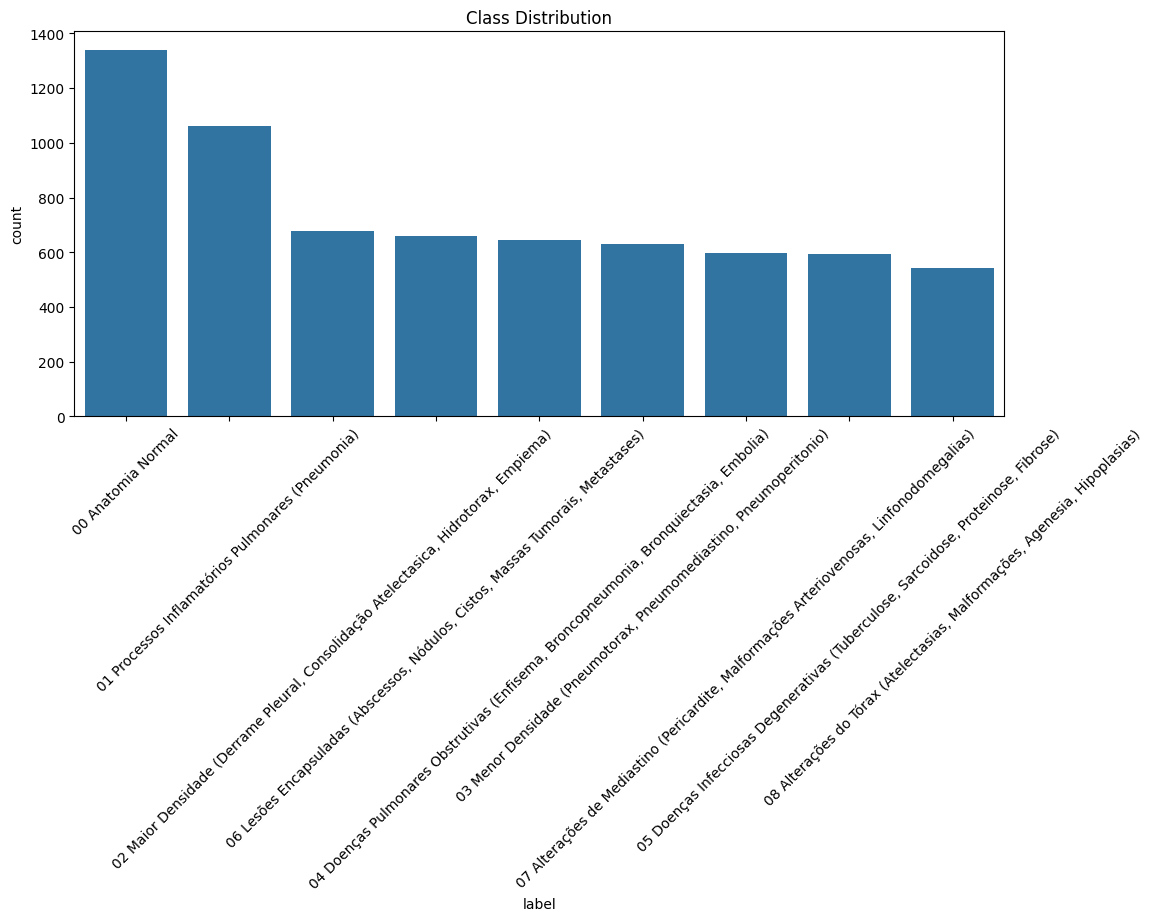

In [6]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x="label", order=df['label'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

EDA (Sample Images)

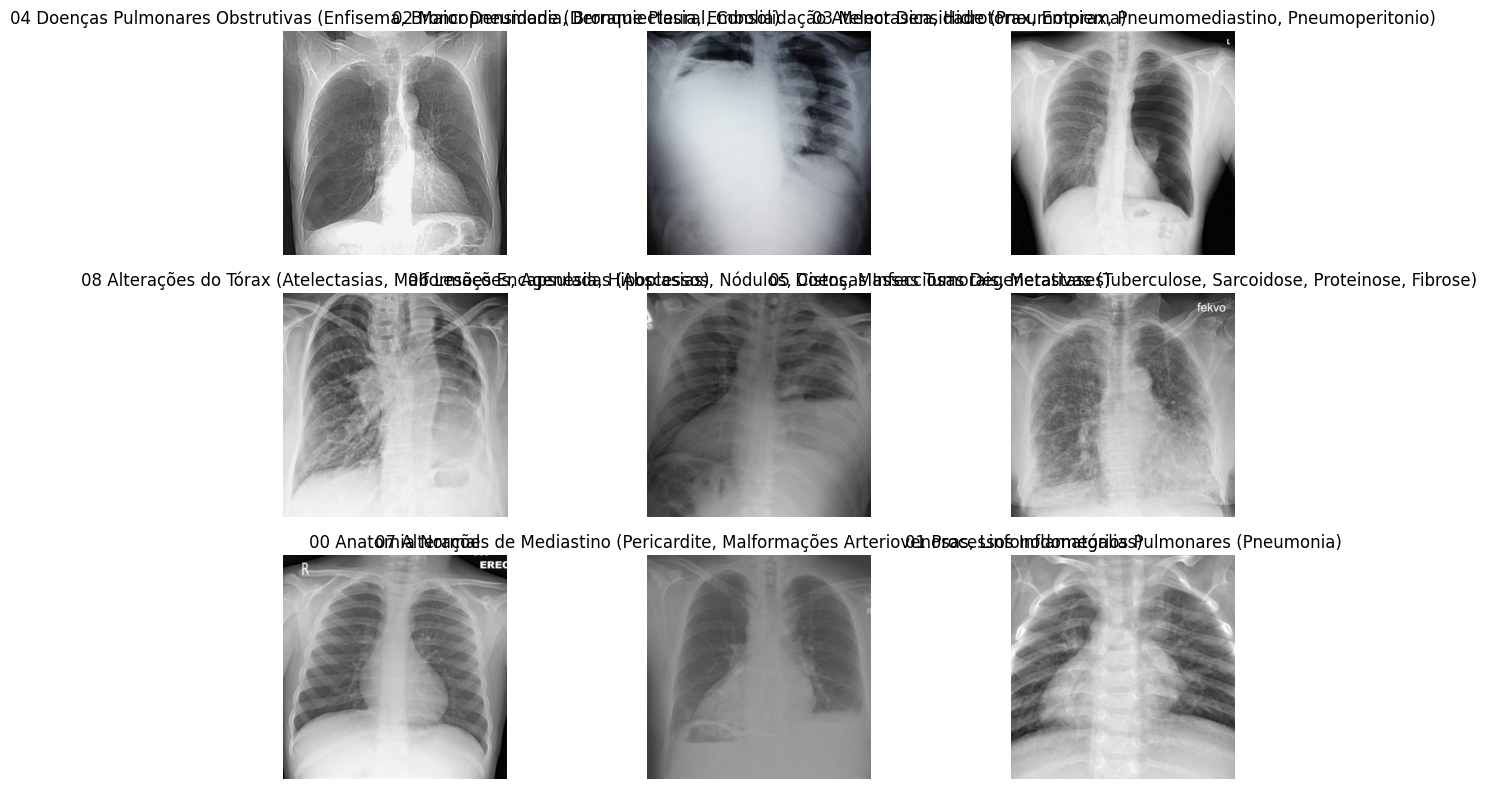

In [7]:
plt.figure(figsize=(12,8))

for i, label in enumerate(df['label'].unique()[:9]):
    img_path = random.choice(df[df['label']==label]['filepath'].values)
    img = cv2.imread(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

Split Data

In [8]:
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

Parameters

In [9]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

Feature Engineering (Augmentation)

In [10]:
train_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess,
    rotation_range=15,       # زود من 10
    zoom_range=0.15,         # زود من 0.1
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],  # زود النطاق
    shear_range=0.1,         # ← جديد
    width_shift_range=0.1,   # ← جديد
    height_shift_range=0.1   # ← جديد
)
eval_datagen = ImageDataGenerator(
    preprocessing_function=efficientnet_preprocess
)

Generators

In [11]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE
)

val_gen = eval_datagen.flow_from_dataframe(
    val_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_gen = eval_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4720 validated image filenames belonging to 9 classes.
Found 1011 validated image filenames belonging to 9 classes.
Found 1012 validated image filenames belonging to 9 classes.


Class Weights

In [12]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weight_dict = dict(enumerate(class_weights))


class_weight_dict[1] *= 2.0

In [13]:
print(train_gen.class_indices)
print(len(train_gen.class_indices))

{'00 Anatomia Normal': 0, '01 Processos Inflamatórios Pulmonares (Pneumonia)': 1, '02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)': 2, '03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)': 3, '04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)': 4, '05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)': 5, '06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Metastases)': 6, '07 Alterações de Mediastino (Pericardite, Malformações Arteriovenosas, Linfonodomegalias)': 7, '08 Alterações do Tórax (Atelectasias, Malformações, Agenesia, Hipoplasias)': 8}
9


Build Model

In [14]:
def build_model(num_classes):
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base_model.trainable = False

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs=base_model.input, outputs=outputs)

num_classes = len(train_gen.class_indices)

model = build_model(num_classes)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,384,940 (16.73 MB)

 Trainable params: 332,809 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

early stopping

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

Training

In [16]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop, checkpoint],
    class_weight=class_weight_dict
)

Epoch 1/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.2030 - loss: 3.0732
Epoch 1: val_accuracy improved from None to 0.61919, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 143s 759ms/step - accuracy: 0.2903 - loss: 2.6201 - val_accuracy: 0.6192 - val_loss: 1.4530
Epoch 2/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.4459 - loss: 1.9479
Epoch 2: val_accuracy improved from 0.61919 to 0.72601, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 77s 519ms/step - accuracy: 0.5004 - loss: 1.7360 - val_accuracy: 0.7260 - val_loss: 1.0020
Epoch 3/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.5380 - loss: 1.5803
Epoch 3: val_accuracy improved from 0.72601 to 0.78042, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 77s 518ms/step - accuracy: 0.5619 - loss: 1.4779 - val_accuracy: 0.7804 - val_loss: 0.7754
Epoch 4/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.6127 - loss: 1.3158
Epoch 4: val_accuracy improved from 0.78042 to 0.80910, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 77s 520ms/step - accuracy: 0.6208 - loss: 1.2904 - val_accuracy: 0.8091 - val_loss: 0.6397
Epoch 5/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.6744 - loss: 1.0978
Epoch 5: val_accuracy improved from 0.80910 to 0.83976, saving model to best_model.h5


...


Epoch 20: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 78s 524ms/step - accuracy: 0.8303 - loss: 0.5544 - val_accuracy: 0.9228 - val_loss: 0.2534
Epoch 21/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.8283 - loss: 0.5651
Epoch 21: val_accuracy improved from 0.92285 to 0.92779, saving model to best_model.h5



Epoch 21: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 78s 522ms/step - accuracy: 0.8320 - loss: 0.5549 - val_accuracy: 0.9278 - val_loss: 0.2427
Epoch 22/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.8435 - loss: 0.5053
Epoch 22: val_accuracy improved from 0.92779 to 0.93076, saving model to best_model.h5



Epoch 22: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 77s 517ms/step - accuracy: 0.8394 - loss: 0.5190 - val_accuracy: 0.9308 - val_loss: 0.2286
Epoch 23/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.8511 - loss: 0.4888
Epoch 23: val_accuracy did not improve from 0.93076
148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 514ms/step - accuracy: 0.8487 - loss: 0.4937 - val_accuracy: 0.9288 - val_loss: 0.2304
Epoch 24/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.8608 - loss: 0.4545
Epoch 24: val_accuracy improved from 0.93076 to 0.93175, saving model to best_model.h5



Epoch 24: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 512ms/step - accuracy: 0.8604 - loss: 0.4641 - val_accuracy: 0.9318 - val_loss: 0.2155
Epoch 25/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.8604 - loss: 0.4636
Epoch 25: val_accuracy improved from 0.93175 to 0.93867, saving model to best_model.h5



Epoch 25: finished saving model to best_model.h5
148/148 ━━━━━━━━━━━━━━━━━━━━ 77s 522ms/step - accuracy: 0.8614 - loss: 0.4657 - val_accuracy: 0.9387 - val_loss: 0.2089
Epoch 26/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.8660 - loss: 0.4393
Epoch 26: val_accuracy did not improve from 0.93867
148/148 ━━━━━━━━━━━━━━━━━━━━ 75s 509ms/step - accuracy: 0.8576 - loss: 0.4577 - val_accuracy: 0.9357 - val_loss: 0.2057
Epoch 27/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step - accuracy: 0.8638 - loss: 0.4464
Epoch 27: val_accuracy did not improve from 0.93867
148/148 ━━━━━━━━━━━━━━━━━━━━ 75s 507ms/step - accuracy: 0.8650 - loss: 0.4412 - val_accuracy: 0.9347 - val_loss: 0.2045
Epoch 28/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.8648 - loss: 0.4317
Epoch 28: val_accuracy did not improve from 0.93867
148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 516ms/step - accuracy: 0.8610 - loss: 0.4396 - val_accuracy: 0.9347 - val_loss: 0.1957
Epoch 29/30
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 484

Fine-Tuning

In [17]:
for layer in model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,

)

Epoch 1/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 132s 698ms/step - accuracy: 0.6689 - loss: 0.9592 - val_accuracy: 0.9060 - val_loss: 0.3162
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 514ms/step - accuracy: 0.7244 - loss: 0.8096 - val_accuracy: 0.8912 - val_loss: 0.3449
Epoch 3/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 514ms/step - accuracy: 0.7544 - loss: 0.7215 - val_accuracy: 0.8952 - val_loss: 0.3369
Epoch 4/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 514ms/step - accuracy: 0.7657 - loss: 0.6833 - val_accuracy: 0.8981 - val_loss: 0.3193
Epoch 5/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 512ms/step - accuracy: 0.7771 - loss: 0.6516 - val_accuracy: 0.9031 - val_loss: 0.3040
Epoch 6/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 514ms/step - accuracy: 0.7837 - loss: 0.6305 - val_accuracy: 0.9100 - val_loss: 0.2877
Epoch 7/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 76s 514ms/step - accuracy: 0.8011 - loss: 0.6118 - val_accuracy: 0.9080 - val_loss: 0.2797
Epoch 8/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 77s 517ms/step - accuracy: 0.8150 - loss: 

Evaluation

In [18]:
loss, acc = model.evaluate(test_gen)
print("Test Accuracy:", acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 535ms/step - accuracy: 0.9368 - loss: 0.2124
Test Accuracy: 0.9367588758468628


Accuracy Curve

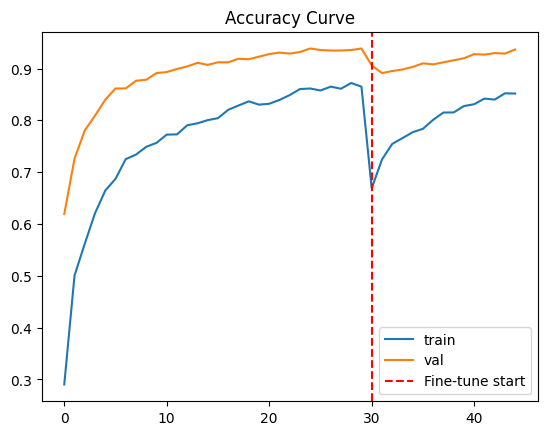

In [19]:
all_acc = history.history['accuracy'] + history_fine.history['accuracy']
all_val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']


plt.plot(all_acc, label='train')
plt.plot(all_val_acc, label='val')
plt.axvline(x=len(history.history['accuracy']), color='red', linestyle='--', label='Fine-tune start')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

Confusion Matrix

32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 320ms/step


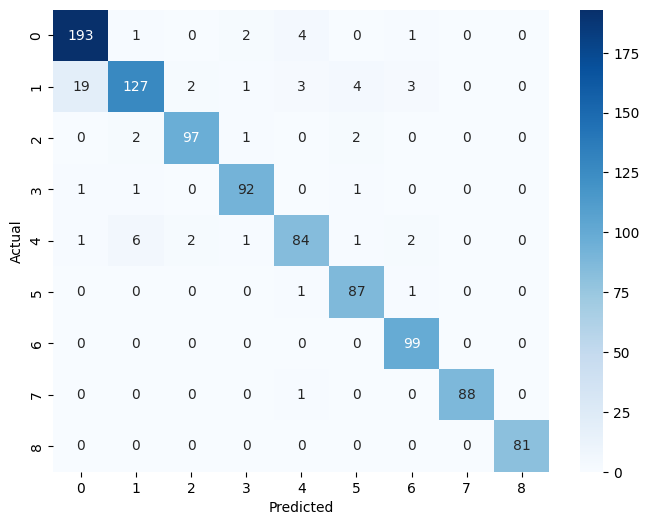

In [20]:
y_true = test_gen.classes
y_pred = np.argmax(model.predict(test_gen), axis=1)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [21]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_gen.class_indices.keys())
))

                                                                                           precision    recall  f1-score   support

                                                                       00 Anatomia Normal       0.90      0.96      0.93       201
                                        01 Processos Inflamatórios Pulmonares (Pneumonia)       0.93      0.80      0.86       159
     02 Maior Densidade (Derrame Pleural, Consolidação Atelectasica, Hidrotorax, Empiema)       0.96      0.95      0.96       102
                      03 Menor Densidade (Pneumotorax, Pneumomediastino, Pneumoperitonio)       0.95      0.97      0.96        95
   04 Doenças Pulmonares Obstrutivas (Enfisema, Broncopneumonia, Bronquiectasia, Embolia)       0.90      0.87      0.88        97
      05 Doenças Infecciosas Degenerativas (Tuberculose, Sarcoidose, Proteinose, Fibrose)       0.92      0.98      0.95        89
         06 Lesões Encapsuladas (Abscessos, Nódulos, Cistos, Massas Tumorais, Meta

Predict Image

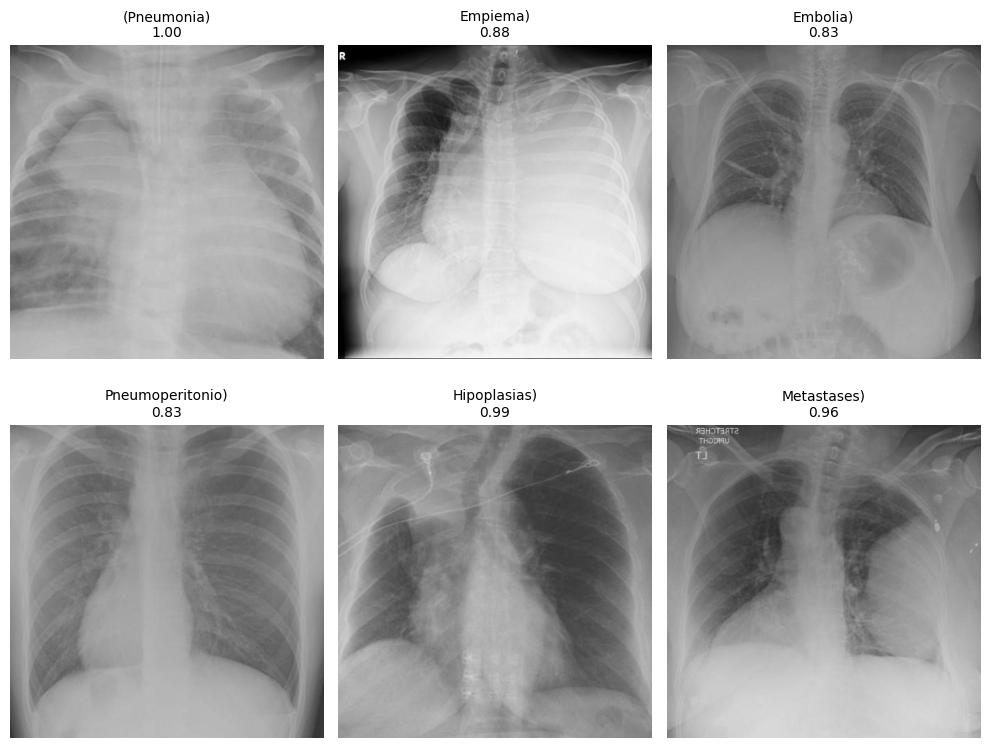

In [22]:
def predict_image(img_path):
    if not os.path.exists(img_path):
        return None, None

    img = cv2.imread(img_path)
    if img is None:
        return None, None

    img_display = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img = cv2.resize(img, (224, 224))
    img = efficientnet_preprocess(img)
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)
    class_idx = np.argmax(pred)
    confidence = np.max(pred)

    class_name = list(train_gen.class_indices.keys())[class_idx]

    short_name = class_name.split(' ')[-1]

    return img_display, f"{short_name}\n{confidence:.2f}"


paths = test_df['filepath'].sample(6).values

plt.figure(figsize=(10, 8))

for i, p in enumerate(paths):
    img, title = predict_image(p)
    if img is None:
        continue

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(title, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()